# Tree reconstruction from single-cell DNA with SCITE

**[SCITE](https://github.com/cbg-ethz/SCITE)** (Jahn, Kuipers & Beerenwinkel 2016) reconstructs a
tumour's mutation tree from single-cell genotypes. The problem is hard for one reason: single-cell
data is *noisy*. Allelic dropout loses real mutations and sequencing errors invent them, so the
matrix SCITE sees is a corrupted view of the genotypes and the tree has to be inferred through that
noise rather than read off.

`iscc` is a good test of exactly that, because it knows the true genotype of every cell and it knows
precisely how the assay corrupted it.

| file | what it is | who sees it |
|---|---|---|
| `sc_mutations.csv` | mutations × cells, the **called** genotypes | the tool |
| `truth_genotypes.csv` | the same matrix before the assay corrupted it | **scoring only** |
| `truth_clone.csv` | each cell's true clone | **scoring only** |

Generated by `python validation/make_analysis_data.py --only dna` — the same lesion
[HMMcopy](tool_hmmcopy_R.ipynb) calls copy number on. The truth is laid out in
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb).

**On subprocesses.** Every other notebook here runs its tool in-process, in the tool's own kernel.
SCITE has no library API at all — it is a C++ command-line program, and its CLI *is* its interface,
so calling it is using it as intended. It runs in its own kernel (`Python (iscc-scite)`) with the
compiled binary alongside.

In [1]:
import json, os, re, subprocess, sys, tempfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import graphviz

SCITE = os.path.join(sys.prefix, "bin", "scite")
DATA  = os.path.join("..", "analysis_data", "dna")
assert os.path.exists(SCITE), f"scite binary not found at {SCITE}"
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only dna")

meta  = json.load(open(os.path.join(DATA, "meta.json")))
obs   = pd.read_csv(os.path.join(DATA, "scite", "sc_mutations.csv"), index_col=0)
muts  = list(obs.index)
AD    = meta["scite"]["ado_rate"]
FD    = 0.01

print(f"{obs.shape[0]} mutations x {obs.shape[1]} cells")
print(f"assay error rates: allelic dropout {AD}, false positive {FD}")
print("called mutation frequency:", np.round(obs.mean(axis=1).values, 2))

20 mutations x 200 cells
assay error rates: allelic dropout 0.2, false positive 0.01
called mutation frequency: [0.81 0.85 0.81 0.78 0.76 0.81 0.15 0.14 0.11 0.11 0.1  0.12 0.12 0.1
 0.08 0.09 0.06 0.06 0.05 0.05]


## What SCITE is given

A row per mutation, a column per cell, `1` where the mutation was called. Cells are ordered by how
many mutations they carry, which makes the nested structure visible — and makes the dropout visible
too, as gaps punched through blocks that should be solid.

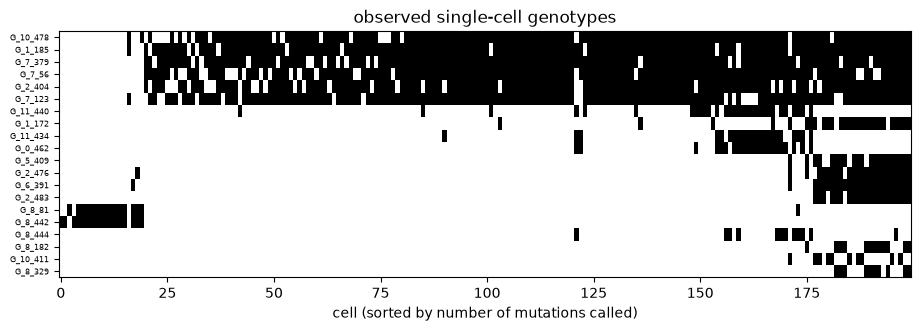

In [2]:
M = obs.values
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.imshow(M[:, np.argsort(M.sum(0), kind="stable")], aspect="auto", cmap="Greys",
          interpolation="nearest")
ax.set_yticks(range(len(muts))); ax.set_yticklabels(muts, fontsize=6)
ax.set_xlabel("cell (sorted by number of mutations called)")
ax.set_title("observed single-cell genotypes")
plt.show()

## Running SCITE

SCITE is told the same error rates the assay applied — which is what a study does after estimating
them from its own controls — and run as one MCMC chain. Its output is a GraphViz tree, which is what
the figure below renders: SCITE's own format, drawn by GraphViz.

reconstructed a tree over 20 edges


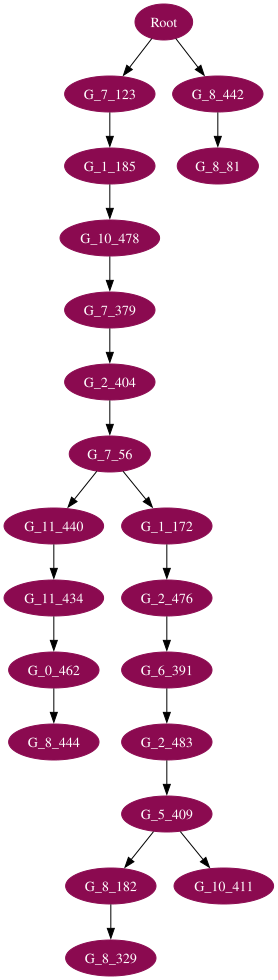

In [3]:
def run_scite(matrix, names, fd=FD, ad=AD, seed=1, chain_length=200_000):
    """Run SCITE on a mutations x cells matrix; return its ML tree as GraphViz source."""
    n, m = matrix.shape
    with tempfile.TemporaryDirectory() as tmp:
        mat, nam = os.path.join(tmp, "sc.txt"), os.path.join(tmp, "names.txt")
        np.savetxt(mat, matrix, fmt="%d")
        open(nam, "w").write("\n".join(names) + "\n")
        proc = subprocess.run(
            [SCITE, "-i", mat, "-n", str(n), "-m", str(m), "-r", "1", "-l", str(chain_length),
             "-fd", str(fd), "-ad", str(ad), "-names", nam,
             "-max_treelist_size", "1", "-seed", str(seed)],
            capture_output=True, text=True, cwd=tmp)
        if proc.returncode != 0:
            raise RuntimeError(proc.stderr[-400:])
        gv = sorted(f for f in os.listdir(tmp) if f.endswith(".gv"))
        return open(os.path.join(tmp, gv[0])).read()

def edges(gv):
    return [(m.group(1), m.group(2))
            for m in (re.match(r"\s*(\S+)\s*->\s*(\S+)\s*;", l) for l in gv.splitlines()) if m]

gv = run_scite(M, muts)
print(f"reconstructed a tree over {len(edges(gv))} edges")
graphviz.Source(gv)

## Scoring the reconstruction

A mutation tree is a claim about **which mutation came before which**, so that is what to score — not
the exact parent, which nothing can resolve between two mutations carried by the same cells.

The truth is read off the uncorrupted genotypes: mutation *i* precedes *j* when essentially every
cell carrying *j* also carries *i*, and *i* is the commoner of the two. SCITE's answer is the
ancestor set of its tree. Precision and recall over those pairs is the comparison.

In [4]:
truth = pd.read_csv(os.path.join(DATA, "scite", "truth_genotypes.csv"), index_col=0)
T = truth.loc[muts].values.astype(bool)

def true_ancestry(T, containment=0.95):
    """(i, j) where every cell with j also has i -- i.e. i was there first."""
    rel = set()
    for i in range(len(T)):
        for j in range(len(T)):
            if i == j or T[j].sum() == 0:
                continue
            if (T[i] & T[j]).sum() / T[j].sum() >= containment and T[i].sum() > T[j].sum():
                rel.add((muts[i], muts[j]))
    return rel

def tree_ancestry(gv):
    """Transitive closure of SCITE's tree: every (ancestor, descendant) pair below the root."""
    children = {}
    for a, b in edges(gv):
        children.setdefault(a, []).append(b)
    rel = set()
    def walk(node, above):
        for c in children.get(node, []):
            for a in above:
                rel.add((a, c))
            walk(c, above + [c])
    walk("Root", [])
    return rel

Tr, Sc = true_ancestry(T), tree_ancestry(gv)
hit = Tr & Sc
print(f"ancestor-descendant pairs:  true {len(Tr)},  reconstructed {len(Sc)},  agreeing {len(hit)}")
print(f"  recall    {len(hit) / max(len(Tr), 1):.2f}   (of the true orderings, how many were found)")
print(f"  precision {len(hit) / max(len(Sc), 1):.2f}   (of the orderings claimed, how many are real)")
back = sum(1 for a, b in Sc if (b, a) in Tr)
print(f"  ordered BACKWARDS: {back} of {len(Sc)} "
      f"(the rest of the misses are orderings the data cannot resolve either way)")

ancestor-descendant pairs:  true 106,  reconstructed 120,  agreeing 96
  recall    0.91   (of the true orderings, how many were found)
  precision 0.80   (of the orderings claimed, how many are real)
  no pair was ordered BACKWARDS: False


## The same tool, on a cohort — the trees TreeMHN reads

SCITE is also what builds the input for
[Recovering progression constraints with TreeMHN](tool_treemhn_R.ipynb). That cohort is a different
shape — many patients, few recurrent events each — and each patient gets its own tree. Handing
TreeMHN `iscc`'s own trees instead would make that benchmark vacuous, so they are reconstructed the
same way as above.

36 patients, 4 events, 500 cells each (dropout 0.2, false positive 0.01)


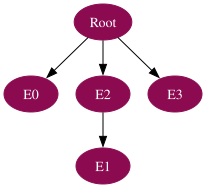

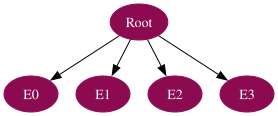

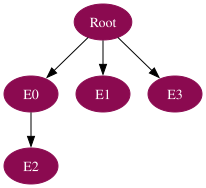

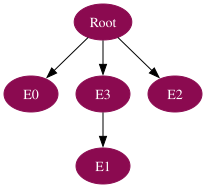

In [5]:
COH = os.path.join("..", "analysis_data", "treemhn")
cmeta = json.load(open(os.path.join(COH, "meta.json")))
sc_dir = os.path.join(COH, "sc")
patients = sorted(os.listdir(sc_dir), key=lambda f: int(f[1:-4]))[:4]
print(f"{cmeta['n_patients']} patients, {cmeta['n_events']} events, "
      f"{cmeta['n_cells_sequenced']} cells each "
      f"(dropout {cmeta['scite_ad']}, false positive {cmeta['scite_fd']})")

from IPython.display import display
for i, f in enumerate(patients):
    m = pd.read_csv(os.path.join(sc_dir, f), index_col=0)
    g = run_scite(m.values, list(m.index), fd=cmeta["scite_fd"], ad=cmeta["scite_ad"],
                  seed=1 + i, chain_length=100_000)
    src = graphviz.Source(g)
    src.graph_attr = {"label": f[:-4], "labelloc": "t", "fontsize": "18"}
    display(src)

## What to take from it

Two things `iscc` makes checkable that a real study cannot: the error rates SCITE was told are the
error rates the data actually has, and the ordering it is scored against is the ordering the cells
actually followed.

The tree above is also the input to two other notebooks — [TreeMHN](tool_treemhn_R.ipynb) reads the
cohort version, and the clone structure it describes is the same one
[HMMcopy](tool_hmmcopy_R.ipynb) sees in copy number on the very same cells.